# Raw CPG Node and Edge Analysis

This notebook analyzes the raw Code Property Graph (CPG) output generated by Joern before it is filtered by CodeGraphene. 

While CodeGraphene currently abstracts these graphs into line, method, or file-level granularities, advanced LLM alignment requires token-level embeddings. To make the future implementation of token-level granularity possible, an understanding of the underlying CPG structure is necessary.

The objectives of this analysis are to:
1. Quantify the distribution of raw node and edge types (e.g., `AST` vs. `REACHING_DEF`).
2. Identify which leaf nodes (e.g., `IDENTIFIER`, `LITERAL`, `CALL`) contain the atomic code strings required for LLM tokenization.

In [ ]:
import tempfile
import networkx as nx
import pandas as pd
import matplotlib.pyplot as plt

from codegraphene.parsers.joern import JoernParser

plt.style.use('ggplot')
pd.set_option('display.max_colwidth', None)

In [2]:
test_file = "sample_code.py"
parser = JoernParser()
temp_dir_obj = tempfile.TemporaryDirectory()
temp_dir = temp_dir_obj.name

print("Running Joern parsing...")
dot_file_path = parser._generate_dot_file(test_file, temp_dir)

print("Loading DOT file into NetworkX...")
raw_graph = nx.drawing.nx_pydot.read_dot(dot_file_path)

print(f"Total Nodes: {raw_graph.number_of_nodes()}")
print(f"Total Edges: {raw_graph.number_of_edges()}")

Running Joern parsing...
[JoernParser] Running: joern-parse sample_code.py --output /tmp/tmpwnvqakv3/cpg.bin
[JoernParser] Running: joern-export /tmp/tmpwnvqakv3/cpg.bin --repr all --out /tmp/tmpwnvqakv3/export
Loading DOT file into NetworkX...
Total Nodes: 466
Total Edges: 3201


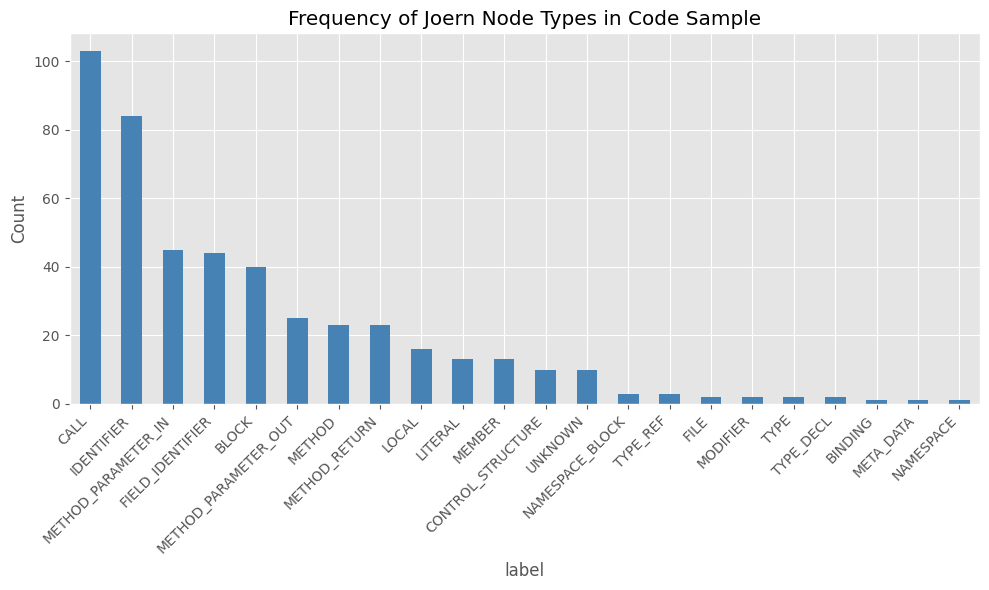

,Node Label (Type),Count
0,CALL,103
1,IDENTIFIER,84
2,METHOD_PARAMETER_IN,45
3,FIELD_IDENTIFIER,44
4,BLOCK,40
5,METHOD_PARAMETER_OUT,25
6,METHOD,23
7,METHOD_RETURN,23
8,LOCAL,16
9,LITERAL,13


In [3]:
# Node Type Distribution
node_data = []

for node_id, data in raw_graph.nodes(data=True):
    # Clean up raw string formatting
    clean_data = {k: v.strip('"') if isinstance(v, str) else v for k, v in data.items()}
    
    node_data.append({
        "id": node_id,
        "label": clean_data.get("label", "UNKNOWN"),
        "code": clean_data.get("CODE", ""),
        "line_number": clean_data.get("LINE_NUMBER", None),
        "type_full_name": clean_data.get("TYPE_FULL_NAME", "")
    })

df_nodes = pd.DataFrame(node_data)

node_counts = df_nodes['label'].value_counts().reset_index()
node_counts.columns = ['Node Label (Type)', 'Count']

plt.figure(figsize=(10, 6))
df_nodes['label'].value_counts().plot(kind='bar', color='steelblue')
plt.title("Frequency of Joern Node Types in Code Sample")
plt.ylabel("Count")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

display(node_counts)


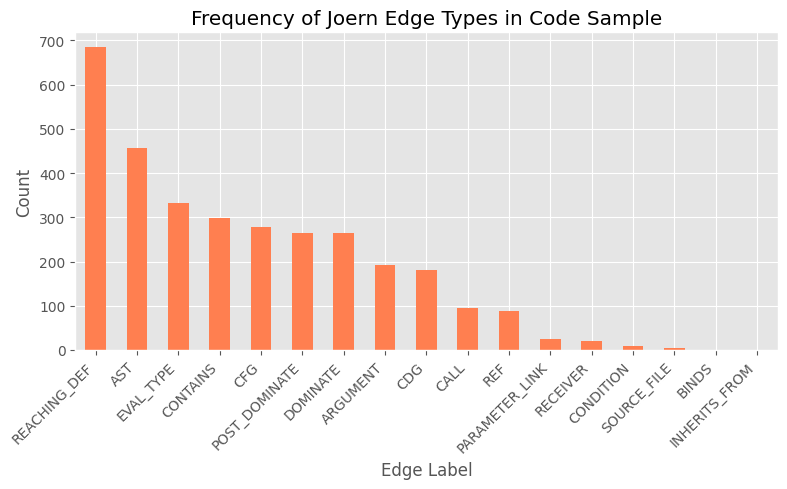

,Edge Label (Type),Count
0,REACHING_DEF,684
1,AST,456
2,EVAL_TYPE,333
3,CONTAINS,299
4,CFG,279
5,POST_DOMINATE,265
6,DOMINATE,265
7,ARGUMENT,192
8,CDG,181
9,CALL,96


In [4]:
# Edge Type Distribution
edge_data = []

for u, v, data in raw_graph.edges(data=True):
    clean_label = data.get("label", '""').strip('"')
    edge_data.append({"Edge Label": clean_label})

df_edges = pd.DataFrame(edge_data)
edge_counts = df_edges['Edge Label'].value_counts().reset_index()
edge_counts.columns = ['Edge Label (Type)', 'Count']

plt.figure(figsize=(8, 5))
df_edges['Edge Label'].value_counts().plot(kind='bar', color='coral')
plt.title("Frequency of Joern Edge Types in Code Sample")
plt.ylabel("Count")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

display(edge_counts)

In [5]:
## Identifying example leaf nodes for token-level granularity
leaf_node_types = ['IDENTIFIER', 'LITERAL', 'FIELD_IDENTIFIER', 'CALL']

df_leaves = df_nodes[df_nodes['label'].isin(leaf_node_types)].copy()
df_leaves = df_leaves[df_leaves['code'] != ""]
df_leaves = df_leaves.dropna(subset=['line_number'])

display(df_leaves[['label', 'code', 'line_number', 'type_full_name']].sample(15))

temp_dir_obj.cleanup()

,label,code,line_number,type_full_name
44,CALL,self._count,4,ANY
57,CALL,self.gas,11,ANY
187,FIELD_IDENTIFIER,ready,58,
185,FIELD_IDENTIFIER,children,57,
271,IDENTIFIER,tmp4,63,__builtin.list
242,IDENTIFIER,self,48,ANY
171,FIELD_IDENTIFIER,_roll_back,39,
250,IDENTIFIER,problem,57,ANY
85,CALL,self.scheduler.step(),40,ANY
231,IDENTIFIER,tmp0,40,ANY
